**PARTE PREVIA**

A continuación realizaremos un estudio sobre los 6 datasets subidos para realizar el trabajo práctico (en adelante TP). Esto será compartido con todo el equipo.

Empezaremos por un análisis previo con el claro objetivo de ver que datasets elegimos para realizar el TP.

**INFORMACIÓN SOBRE LOS DATOS**

*  C. elegans: Una red dirigida y pesada que representa la red de conexiones neuronales en el organismo Caenorhabditis elegans (un nematodo). Cada nodo es una neurona, y cada enlace una conexión entre neuronas. El sistema nervioso de este organismo es el único al cual se le han podido reconstruir todas sus conexiones neuronales. Además, en este dataset también se indica si la conexión sináptica es excitatoria (’exc’) o inhibitoria  (’inh’), así como el peso de la conexión. Contiene 299 nodos y 2279 enlances.

*  Facebook: Una red no dirigida y no pesada de círculos de Facebook. Los datos fueron recogidos por una encuesta realizada en la app de Facebook. Cada nodo es un perfil de Facebook y un enlace significa que los perfiles son amigos en Facebook. Contiene 4039 nodos y 88234 enlaces.

*  Email-EU: Una red no dirigida y no pesada de contactos vía e-mail en una institución europea de investigación. Cada nodo es una persona dentro de la institución, un enlace significa que estas personas intercambiaron al menos un email. Para este dataset también tenemos un label conocido de antemano para cada nodo, que representa a qué departamento de la institución pertenece el nodo. Contiene 1005 nodos y 25571 enlaces.

*  Aeropuertos: Una red dirigida y pesada. Cada nodo es un aeropuerto de Estados Unidos, y los enlaces representan vuelos realizados en el año 2025. El peso de cada enlace indica el número total de vuelos de dicha ruta. Hay información sobre las coordenadas espaciales de cada aeropuerto. Contiene 1252 nodos y 23092 enlaces.

*  CONICET: Una red no dirigida y no pesada. Cada nodo es un autor de un subconjunto de la base de datos del CONICET para las publicaciones entre 2023 y 2024.
Tiene metadatos de los autores con sus áreas de investigación. Tiene 8288 nodos y 14105 enlaces.

*  Bariloche: Una red dirigida y pesada construida a partir de la información disponible en OpenStreetMap (vía el paquete osmnx). Cada nodo es una intersección y cada enlace una vía manejable. Contiene metadatos adicionales con la ubicación, tipo de vía y velocidad máxima, entre otros. Tiene 4905 nodos y 13582 enlaces.

**SET DE INDICADORES PARA REALIZAR EL ANÁLISIS E INSPECCIÓN DE LOS DATASETS PREVIA ELECCIÓN**

*  Características de las redes: es dirigído?, es pesado? es conectado? es fuertemente conexo? es debilmente conexo?
*  Análisis de componente gigante: borrando autoenlaces, analizamos su conexión
*  Realizamos una visualización espacial de cada nodo si existe información sobre posición.
*  Grados de nodo
*  Coeficiente de clustering
*  Coeficiente de transitividad
*  Coeficiente de asortatividad
*  Distancias mínimas medias

In [64]:
import matplotlib.pyplot as plt
import os

# Números y Datos
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
import community.community_louvain as cl

import pandas as pd
import pickle

In [1]:
# DATOS REDES:
!wget -O datasets-tp1.zip https://www.dropbox.com/scl/fi/ke7kyfox7w6hnmcnt3x2b/datasets-tp1.zip?rlkey=m7uljexxrljs6bu9pcv8qtyh7&st=09rgvayp&dl=1
!unzip -o datasets-tp1.zip

"wget" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
"st" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
"dl" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
"unzip" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


In [2]:
import os
os.listdir("datasets")

['airport_coords.csv',
 'airport_graph.csv',
 'bariloche_calles.graphml',
 'celegans_connectome.csv',
 'celegans_positions.csv',
 'colaboracionesCONICET_2023_2024_filtrado.graphml',
 'conicet_pos.pkl',
 'email-Eu-core-department-labels.txt',
 'email-Eu-core.txt',
 'email_positions.pkl',
 'facebook.txt',
 'fb_positions.pkl']

Este dataset nos permite algo que otros no:

👉 análisis espacial + topológico

Podés hacer cosas como:

visualizar rutas en mapa
ver hubs (centralidad alta) geográficamente
analizar si los nodos importantes están distribuidos o concentrados

In [4]:
import pandas as pd
import networkx as nx

# =========================
# EDGES
# =========================
df_edges = pd.read_csv('datasets/airport_graph.csv')

G = nx.from_pandas_edgelist(
    df_edges,
    source='ORIGIN_AIRPORT_ID',
    target='DEST_AIRPORT_ID',
    edge_attr='PASSENGERS',
    create_using=nx.DiGraph()
)

# =========================
# NODES (coords)
# =========================
df_nodes = pd.read_csv('datasets/airport_coords.csv')

attrs = df_nodes.set_index('AIRPORT_ID')[['LATITUDE','LONGITUDE']].to_dict('index')
nx.set_node_attributes(G, attrs)

In [5]:
df_edges.head()

,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,PASSENGERS
0,10001,10056,1.0
1,10001,10056,1.0
2,10006,10056,1.0
3,10009,10170,1.0
4,10040,11630,1.0


In [6]:
df_nodes.head()

,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,DISPLAY_AIRPORT_CITY_NAME_FULL,AIRPORT_COUNTRY_NAME,AIRPORT_STATE_NAME,LATITUDE,LONGITUDE,AIRPORT_IS_LATEST
0,10001,01A,Afognak Lake Airport,"Afognak Lake, AK",United States,Alaska,58.109444,-152.906667,1
1,10003,03A,Bear Creek Mining Strip,"Granite Mountain, AK",United States,Alaska,65.548056,-161.071667,1
2,10004,04A,Lik Mining Camp,"Lik, AK",United States,Alaska,68.083333,-163.166667,1
3,10005,05A,Little Squaw Airport,"Little Squaw, AK",United States,Alaska,67.570000,-148.183889,1
4,10006,06A,Kizhuyak Bay,"Kizhuyak, AK",United States,Alaska,57.745278,-152.882778,1


# PARA EL GRAFO TOTAL

In [7]:
def diagnostico_grafo(G, nombre):
    print(f"--- Diagnóstico: {nombre} ---")
    print(G)

    # 1. Dirección
    dirigido = nx.is_directed(G)
    print(f'¿Es dirigido?: {dirigido}')

    # 2. Peso (adaptado a tu dataset)
    es_pesado = any('PASSENGERS' in data for u, v, data in G.edges(data=True))
    print(f'¿Es pesado?: {es_pesado}')

    # 3. Conectividad
    if dirigido:
        conexo_debil = nx.is_weakly_connected(G)
        conexo_fuerte = nx.is_strongly_connected(G)
        print(f'¿Es conexo (débil)?: {conexo_debil}')
        print(f'¿Es conexo (fuerte)?: {conexo_fuerte}')
    else:
        conexo = nx.is_connected(G)
        print(f'¿Es conectado?: {conexo}')

    print('\n')

# Ejecutar
diagnostico_grafo(G, "Red de aeropuertos")

--- Diagnóstico: Red de aeropuertos ---
DiGraph with 1252 nodes and 23092 edges
¿Es dirigido?: True
¿Es pesado?: True
¿Es conexo (débil)?: False
¿Es conexo (fuerte)?: False




“El grafo construido es dirigido y ponderado, donde las aristas representan vuelos entre aeropuertos y el peso corresponde al número de pasajeros. La red no resulta débilmente conexa, lo que indica la existencia de múltiples componentes. Sin embargo, la gran mayoría de los nodos (1239 de 1252) pertenece a una única componente gigante, lo que evidencia que la fragmentación es marginal y que el sistema presenta una conectividad global elevada.”

In [8]:
# =========================
# LIMPIEZA DEL GRAFO
# =========================

# 1. Componentes
n_componentes = nx.number_weakly_connected_components(G)
print(f"Número de componentes: {n_componentes}")

# 2. Componente gigante
G_main = G.subgraph(max(nx.weakly_connected_components(G), key=len)).copy()

# 3. Eliminar autoenlaces
n_loops = nx.number_of_selfloops(G_main)
G_main.remove_edges_from(nx.selfloop_edges(G_main))

# 4. Verificación
print(f"Nodos finales: {len(G_main.nodes())}")
print(f"Enlaces finales: {len(G_main.edges())}")
print(f"Autoenlaces eliminados: {n_loops}")
print(f"¿Conexo débil?: {nx.is_weakly_connected(G_main)}")

Número de componentes: 7
Nodos finales: 1239
Enlaces finales: 22917
Autoenlaces eliminados: 166
¿Conexo débil?: True


La componente gigante contiene aproximadamente el 99% de los nodos, lo que indica que la fragmentación es marginal y que la gran mayoría de los aeropuertos pertenece a una única estructura conectada.
Este resultado justifica restringir el análisis a la componente gigante para el cálculo de métricas globales, ya que los nodos restantes tienen un impacto despreciable en la estructura general.

**PARA EL GRAFO COMPLETO**

In [9]:
import networkx as nx
import numpy as np

# =========================
# INFO GENERAL
# =========================
print("=== GRAFO DIRIGIDO ===")
print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

# =========================
# GRADO PROMEDIO (total)
# =========================
degrees = [d for n, d in G.degree()]
avg_degree = np.mean(degrees)

print("Grado promedio (total):", avg_degree)

# =========================
# GRADO ENTRADA / SALIDA
# =========================
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

print("Grado de entrada promedio:", np.mean(in_degrees))
print("Grado de salida promedio:", np.mean(out_degrees))

# =========================
# CLUSTERING (requiere no dirigido)
# =========================
G_und = G.to_undirected()

clustering = nx.average_clustering(G_und)
print("Clustering (sobre versión no dirigida):", clustering)

# =========================
# TRANSITIVIDAD
# =========================
transitivity = nx.transitivity(G_und)
print("Transitividad:", transitivity)

# =========================
# ASORTATIVIDAD (grado total)
# =========================
assortativity = nx.degree_assortativity_coefficient(G_und)
print("Asortatividad:", assortativity)

# =========================
# COMPONENTE GIGANTE (para distancias)
# =========================
largest_cc = max(nx.weakly_connected_components(G), key=len)
G_gc = G.subgraph(largest_cc).to_undirected().copy()

# =========================
# DISTANCIA MEDIA
# =========================
avg_path = nx.average_shortest_path_length(G_gc)
print("Distancia mínima media:", avg_path)

=== GRAFO DIRIGIDO ===
Nodos: 1252
Aristas: 23092
Grado promedio (total): 36.88817891373802
Grado de entrada promedio: 18.44408945686901
Grado de salida promedio: 18.44408945686901
Clustering (sobre versión no dirigida): 0.4298565601282743
Transitividad: 0.4229225316649961
Asortatividad: 0.05910212964775398
Distancia mínima media: 3.320195425723752


In [10]:
diameter = nx.diameter(G_gc)
print("Diámetro de la red:", diameter) #Tamaño global como “extensión” (diámetro) 
#Otra definición clave es el diámetro de la red: la distancia más larga entre dos nodos.
# ⚠️ Se calcula sobre la componente gigante y en no dirigido:

Diámetro de la red: 8


In [13]:
total_weight = sum(d['PASSENGERS'] for u, v, d in G.edges(data=True))
print("Total de pasajeros transportados en la red:", total_weight) #amaño ponderado (si querés usar los vuelos)
#Como tu red es pesada, podés medir el “tamaño total” en términos de tráfico
#👉 Esto es interesante porque refleja la escala real del sistema.

Total de pasajeros transportados en la red: 67004397.0


“La red presenta un coeficiente de clustering elevado (≈0.43), acompañado de una transitividad de valor similar, lo que indica una fuerte presencia de estructuras locales y agrupamientos entre aeropuertos. Este resultado sugiere la existencia de conexiones regionales densas.

La distancia mínima media (≈3.32) es baja en relación al tamaño de la red, evidenciando una alta eficiencia en la conectividad global. Este comportamiento es consistente con propiedades de redes de tipo pequeño mundo, donde coexisten alta cohesión local y caminos cortos entre nodos.

Por otro lado, la asortatividad presenta un valor levemente positivo (≈0.06), cercano a cero, lo que indica una tendencia débil a que nodos con grados similares se conecten entre sí. Este resultado sugiere que la red no responde estrictamente a una estructura tipo hub-and-spoke, sino que combina conexiones entre nodos altamente conectados con interacciones entre aeropuertos de menor grado, reflejando una organización más compleja.”

**PARA EL GRAFO CON SOLO LA COMPONENTE PRINCIPAL**

In [23]:
import networkx as nx
import numpy as np

# =========================
# COMPONENTE GIGANTE
# =========================
largest_cc = max(nx.weakly_connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()

# =========================
# INFO GENERAL
# =========================
print("=== GRAFO (COMPONENTE GIGANTE) ===")
print("Nodos:", G_main.number_of_nodes())
print("Aristas:", G_main.number_of_edges())

# =========================
# GRADO PROMEDIO
# =========================
degrees = [d for n, d in G_main.degree()]
print("Grado promedio:", np.mean(degrees))

# =========================
# GRADO IN / OUT
# =========================
print("Grado entrada promedio:", np.mean([d for n, d in G_main.in_degree()]))
print("Grado salida promedio:", np.mean([d for n, d in G_main.out_degree()]))

# =========================
# VERSION NO DIRIGIDA
# =========================
G_clean = G_main.to_undirected()

# =========================
# CLUSTERING
# =========================
print("Clustering:", nx.average_clustering(G_clean))

# =========================
# TRANSITIVIDAD
# =========================
print("Transitividad:", nx.transitivity(G_clean))

# =========================
# ASORTATIVIDAD
# =========================
print("Asortatividad:", nx.degree_assortativity_coefficient(G_clean))

# =========================
# DISTANCIA MEDIA
# =========================
print("Distancia media:", nx.average_shortest_path_length(G_clean))

=== GRAFO (COMPONENTE GIGANTE) ===
Nodos: 1239
Aristas: 23083
Grado promedio: 37.26069410815173
Grado entrada promedio: 18.630347054075866
Grado salida promedio: 18.630347054075866
Clustering: 0.4343667580957219
Transitividad: 0.4229228697150028
Asortatividad: 0.05817224893830182
Distancia media: 3.320195425723752


In [24]:
degree_centrality = nx.degree_centrality(G_main)
pagerank = nx.pagerank(G_main, weight='PASSENGERS')

In [27]:
# 1. Grafo completo
G_main = nx.from_pandas_edgelist(
    df_edges,
    source='ORIGIN_AIRPORT_ID',
    target='DEST_AIRPORT_ID',
    edge_attr='PASSENGERS',
    create_using=nx.DiGraph()
)

# 2. atributos nodos
attrs = df_nodes.set_index('AIRPORT_ID')[['LATITUDE','LONGITUDE']].to_dict('index')
nx.set_node_attributes(G_main, attrs)

# 3. eliminar self loops (ok pero menor impacto)
G_main.remove_edges_from(nx.selfloop_edges(G_main))

# 4. PageRank en TODO el grafo
pagerank = nx.pagerank(G_main, weight='PASSENGERS')

# 5. top nodos
top_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:100]

# 6. subgrafo limpio
G_plot = G_main.subgraph(top_nodes).copy()

# 7. posiciones consistentes
pos = {
    n: (G_main.nodes[n]['LONGITUDE'], G_main.nodes[n]['LATITUDE'])
    for n in G_plot.nodes
}

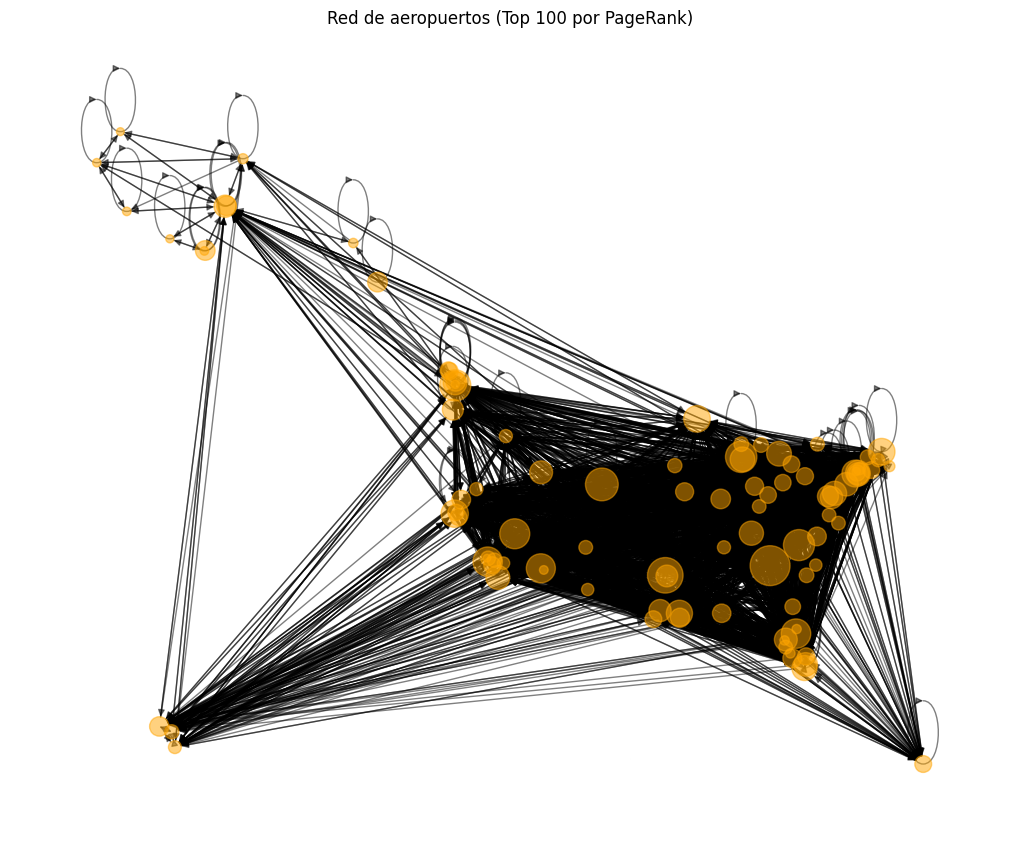

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# =========================
# 1. Cargar datos
# =========================
df_edges = pd.read_csv('datasets/airport_graph.csv')
df_nodes = pd.read_csv('datasets/airport_coords.csv')

# =========================
# 2. Crear grafo dirigido y pesado
# =========================
G = nx.from_pandas_edgelist(
    df_edges,
    source='ORIGIN_AIRPORT_ID',
    target='DEST_AIRPORT_ID',
    edge_attr='PASSENGERS',
    create_using=nx.DiGraph()
)

# =========================
# 3. Agregar coordenadas a nodos
# =========================
attrs = df_nodes.set_index('AIRPORT_ID')[['LATITUDE','LONGITUDE']].to_dict('index')
nx.set_node_attributes(G, attrs)

# =========================
# 4. Filtrar nodos con coordenadas válidas
# =========================
pos = {
    n: (G.nodes[n]['LONGITUDE'], G.nodes[n]['LATITUDE'])
    for n in G.nodes
    if 'LONGITUDE' in G.nodes[n] and 'LATITUDE' in G.nodes[n]
}

# Me quedo solo con la componente principar y con un Subgrafo SOLO con nodos que tienen coordenadas
G_main = G  # grafo solo con el componente principal

G_plot = G_main.subgraph(top_nodes).copy()

# =========================
# 5. Calcular PageRank (importante para tamaño)
# =========================
pagerank = nx.pagerank(G_plot, weight='PASSENGERS')

# =========================
# 6. (OPCIONAL PERO RECOMENDADO) filtrar top nodos
# =========================
top_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:100]
G_plot = G_plot.subgraph(top_nodes).copy()

# actualizar posiciones para esos nodos
pos = {n: pos[n] for n in G_plot.nodes}

# =========================
# 7. Graficar
# =========================
plt.figure(figsize=(10,8))

sizes = [pagerank[n]*20000 for n in G_plot.nodes]

nx.draw(
    G_plot,
    pos,
    node_size=sizes,
    node_color='orange',
    alpha=0.5, 
    with_labels=False
)

plt.title("Red de aeropuertos (Top 100 por PageRank)")
plt.show()

Visualización de la red de aeropuertos

La Figura muestra la red de aeropuertos proyectada en coordenadas geográficas, donde cada nodo representa un aeropuerto y su tamaño es proporcional a su centralidad de PageRank, calculada considerando el peso de las aristas (número de pasajeros). Con el objetivo de mejorar la legibilidad de la visualización, se restringió el análisis a los 100 nodos con mayor centralidad.

Se observa una marcada heterogeneidad en la distribución de la centralidad, con un conjunto reducido de nodos que concentran gran parte de la importancia estructural de la red. Estos nodos corresponden a aeropuertos altamente conectados que actúan como hubs, facilitando el flujo de pasajeros entre distintas regiones. En contraste, la mayoría de los nodos presenta valores de centralidad considerablemente menores, lo que sugiere una organización jerárquica característica de redes de transporte.

Desde el punto de vista espacial, los nodos más centrales se distribuyen en regiones estratégicas del territorio, lo cual refuerza la idea de que la importancia topológica de un aeropuerto está fuertemente asociada a su rol en la conectividad global de la red, más que únicamente a su ubicación geográfica. Esta observación es consistente con propiedades típicas de las Redes libres de escala, donde pocos nodos altamente conectados dominan la estructura.

En conjunto, estos resultados sugieren que la red de aeropuertos presenta una organización no homogénea, con hubs claramente definidos que cumplen un rol crítico en la conectividad global, lo cual tiene implicancias directas en la eficiencia del transporte y en la vulnerabilidad del sistema frente a fallas en nodos clave.

“La centralidad de PageRank, basada en un esquema recursivo similar a la centralidad de autovector, permite identificar nodos cuya importancia emerge no solo de su conectividad local sino también de la relevancia de sus vecinos en la red.”

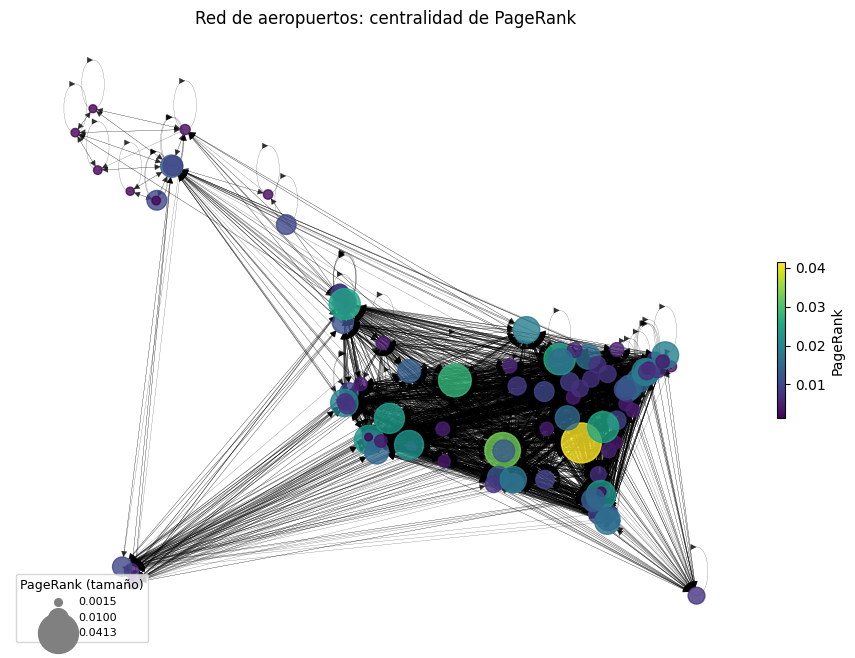

In [32]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

sizes = [pagerank[n]*20000 for n in G_plot.nodes]
node_colors = [pagerank[n] for n in G_plot.nodes]

nx.draw(
    G_plot,
    pos,
    ax=ax,
    node_size=sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    edge_color='black',   # 👈 ahora negro
    width=0.15,           # 👈 más finas
    alpha=0.8,
    with_labels=False
)

# 🔹 Colorbar más chico y proporcionado
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    fraction=0.01,   # 👈 achica el ancho
    pad=0.02         # 👈 separación del gráfico
)
cbar.set_label("PageRank", fontsize=10)

# 🔹 Escala de tamaños más prolija
for val in [min(node_colors), np.mean(node_colors), max(node_colors)]:
    ax.scatter([], [], s=val*20000, color='gray', label=f"{val:.4f}")

ax.legend(
    title="PageRank (tamaño)",
    loc='lower left',
    fontsize=8,
    title_fontsize=9
)

ax.set_title("Red de aeropuertos: centralidad de PageRank")
plt.show()

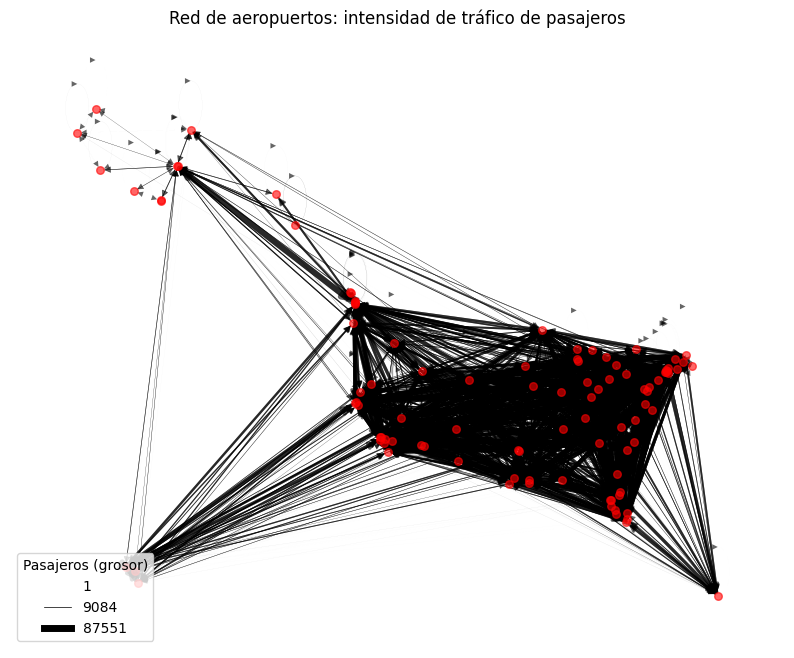

In [33]:
# =========================
# FIGURA 2: Aristas (peso)
# =========================
fig, ax = plt.subplots(figsize=(10,8))

# extraer pesos
edges = G_plot.edges(data=True)
weights = [d['PASSENGERS'] for (_,_,d) in edges]

# normalizar grosores
max_w = max(weights)
widths = [w / max_w * 5 for w in weights]

nx.draw(
    G_plot,
    pos,
    ax=ax,
    node_size=30,              # nodos chicos para no tapar
    node_color='red',
    edge_color='black',
    width=widths,
    alpha=0.6,
    with_labels=False
)

# 🔹 Escala de grosores (manual)
import numpy as np
for w in [min(weights), np.mean(weights), max(weights)]:
    ax.plot([], [], linewidth=w/max_w*5, color='black', label=f"{int(w)}")

ax.legend(title="Pasajeros (grosor)", loc='lower left')

ax.set_title("Red de aeropuertos: intensidad de tráfico de pasajeros")
plt.show()

In [34]:
# recalcular sobre TODO el grafo
pagerank_full = nx.pagerank(G, weight='PASSENGERS')
betweenness_full = nx.betweenness_centrality(G, weight='PASSENGERS', normalized=True)

# ordenar correctamente
pr_order = sorted(pagerank_full, key=pagerank_full.get, reverse=True)
bet_order = sorted(betweenness_full, key=betweenness_full.get, reverse=True)

“Los tamaños de los nodos fueron reescalados linealmente para mejorar la legibilidad de la visualización, preservando las relaciones relativas entre valores de centralidad.”

In [35]:
def scale_sizes(values, min_size=50, max_size=1200):
    v = list(values)
    v_min, v_max = min(v), max(v)

    if v_max == v_min:
        return [min_size for _ in v]

    return [
        min_size + (val - v_min) / (v_max - v_min) * (max_size - min_size)
        for val in v
    ]

"Centralidad de grado"

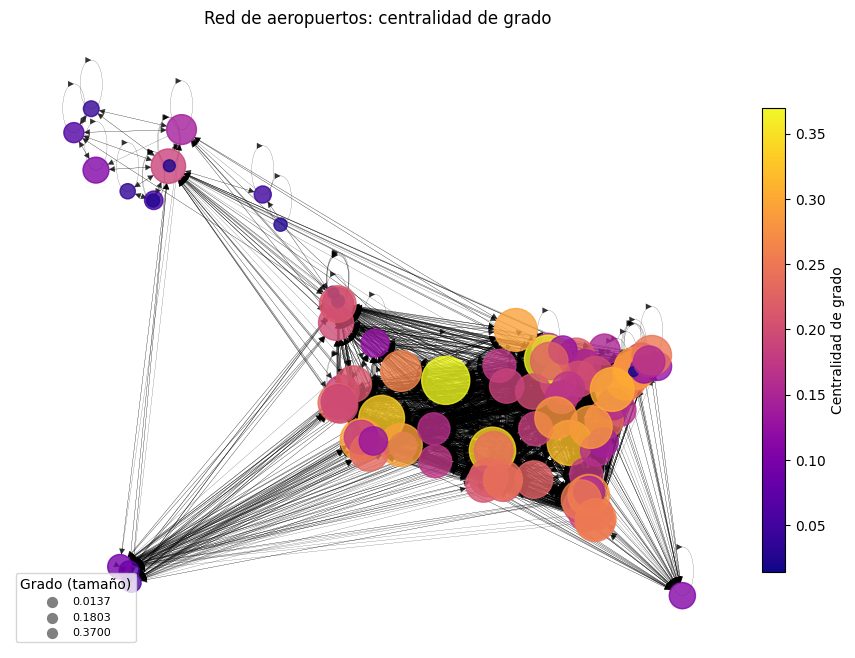

In [36]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

# valores
deg_values = [degree_centrality[n] for n in G_plot.nodes]

# tamaños normalizados
sizes = scale_sizes(deg_values)

# colores
node_colors = deg_values

nx.draw(
    G_plot,
    pos,
    ax=ax,
    node_size=sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    edge_color='black',
    width=0.15,
    alpha=0.8,
    with_labels=False
)

# colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.plasma,
    norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Centralidad de grado")

# escala tamaños (manual)
for val in [min(deg_values), np.mean(deg_values), max(deg_values)]:
    ax.scatter([], [], s=scale_sizes([val])[0], color='gray', label=f"{val:.4f}")

ax.legend(title="Grado (tamaño)", loc='lower left', fontsize=8)

ax.set_title("Red de aeropuertos: centralidad de grado")
ax.axis('off')

plt.show()

#"Centralidad de intermediacion"

In [39]:
# =========================
# calcular betweenness
# =========================
betweenness_centrality = nx.betweenness_centrality(G_plot, weight='PASSENGERS')

# valores
bet_values = [betweenness_centrality[n] for n in G_plot.nodes]

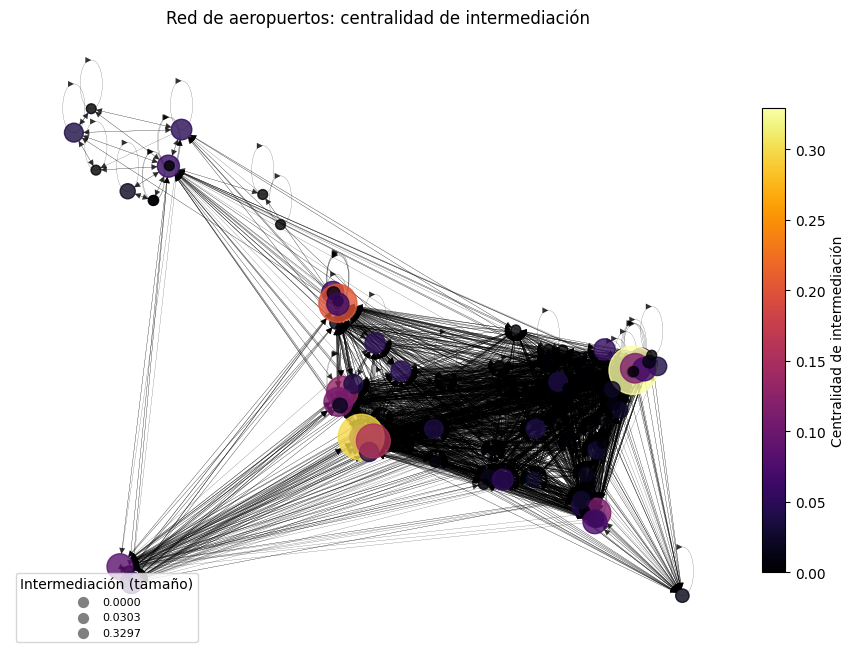

In [40]:
fig, ax = plt.subplots(figsize=(10,8))

# valores
bet_values = [betweenness_centrality[n] for n in G_plot.nodes]

# tamaños normalizados
sizes = scale_sizes(bet_values)

# colores
node_colors = bet_values

nx.draw(
    G_plot,
    pos,
    ax=ax,
    node_size=sizes,
    node_color=node_colors,
    cmap=plt.cm.inferno,
    edge_color='black',
    width=0.15,
    alpha=0.8,
    with_labels=False
)

# colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.inferno,
    norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Centralidad de intermediación")

# escala tamaños
for val in [min(bet_values), np.mean(bet_values), max(bet_values)]:
    ax.scatter([], [], s=scale_sizes([val])[0], color='gray', label=f"{val:.4f}")

ax.legend(title="Intermediación (tamaño)", loc='lower left', fontsize=8)

ax.set_title("Red de aeropuertos: centralidad de intermediación")
ax.axis('off')

plt.show()

“Mientras que la centralidad de grado identifica nodos altamente conectados, la centralidad de intermediación permite detectar nodos críticos para la conectividad global, que actúan como puentes entre distintas regiones de la red.”

In [41]:
# recalcular el G_maim
pagerank_full = nx.pagerank(G_main, weight='PASSENGERS')
betweenness_full = nx.betweenness_centrality(G, weight='PASSENGERS', normalized=True)

# ordenar correctamente
pr_order = sorted(pagerank_full, key=pagerank_full.get, reverse=True)
bet_order = sorted(betweenness_full, key=betweenness_full.get, reverse=True)

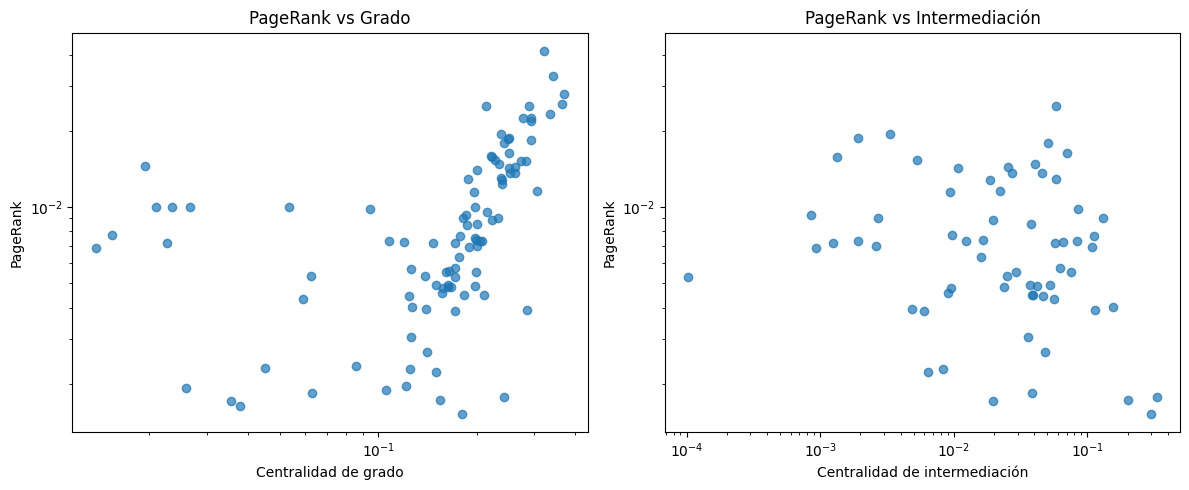

In [42]:
import matplotlib.pyplot as plt

# =========================
# 1. Extraer valores
# =========================
pr_values = [pagerank[n] for n in G_plot.nodes]
deg_values = [degree_centrality[n] for n in G_plot.nodes]
bet_values = [betweenness_centrality[n] for n in G_plot.nodes]

# =========================
# 2. Crear figura
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -------------------------
# 🔵 PageRank vs Grado
# -------------------------
axes[0].scatter(deg_values, pr_values, alpha=0.7)

axes[0].set_xlabel("Centralidad de grado")
axes[0].set_ylabel("PageRank")
axes[0].set_title("PageRank vs Grado")

# escala log (opcional pero recomendada)
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# -------------------------
# 🔴 PageRank vs Intermediación
# -------------------------
axes[1].scatter(bet_values, pr_values, alpha=0.7)

axes[1].set_xlabel("Centralidad de intermediación")
axes[1].set_ylabel("PageRank")
axes[1].set_title("PageRank vs Intermediación")

# escala log
axes[1].set_xscale('log')
axes[1].set_yscale('log')

# =========================
# 3. Mostrar
# =========================
plt.tight_layout()
plt.show()

“Se observa una relación positiva entre la centralidad de grado y PageRank, aunque con una marcada dispersión y una concentración de nodos en valores similares de grado, lo que sugiere que la conectividad local no determina de manera unívoca la importancia global de un nodo. En particular, la presencia de nodos con alto PageRank y grado moderado indica la influencia de la estructura global de la red.

En contraste, la relación entre PageRank y la centralidad de intermediación es más débil y dispersa, sin una tendencia clara, lo que evidencia que los nodos que actúan como puentes estructurales no necesariamente coinciden con aquellos de mayor relevancia global en términos de flujo.”
“Esto sugiere que distintas medidas de centralidad capturan aspectos complementarios de la red.”

Ahora voy a evaluar robustez, en particular , voy a probar la siguiente hipotesis: “La red de aeropuertos será más vulnerable a la remoción de nodos con alta centralidad de intermediación que a la remoción de nodos al azar.”

Vamos a comparar:
1.   eliminación aleatoria
2.   eliminación por PageRank
3.  eliminación por intermediación

Nodos en grafo: 1252
Nodos en PR order: 1252
Nodos en Bet order: 1252


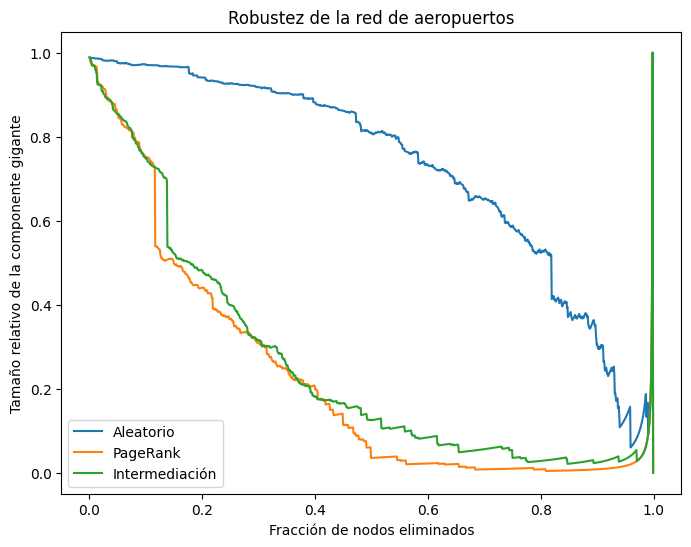

In [43]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# =========================
# 1. Usar grafo NO dirigido
# =========================
G_und = G.to_undirected()

# =========================
# 2. Centralidades (sobre TODO el grafo)
# =========================
pagerank_full = nx.pagerank(G_und, weight='PASSENGERS')
betweenness_full = nx.betweenness_centrality(G_und, weight='PASSENGERS', normalized=True)

# =========================
# 3. Órdenes de eliminación
# =========================
nodes = list(G_und.nodes)

random_order = nodes.copy()
random.shuffle(random_order)

pr_order = sorted(pagerank_full, key=pagerank_full.get, reverse=True)
bet_order = sorted(betweenness_full, key=betweenness_full.get, reverse=True)

# 🔍 chequeo importante
print("Nodos en grafo:", len(nodes))
print("Nodos en PR order:", len(pr_order))
print("Nodos en Bet order:", len(bet_order))

# =========================
# 4. Función componente gigante
# =========================
def giant_component_fraction(G):
    if len(G) == 0:
        return 0
    largest_cc = max(nx.connected_components(G), key=len)
    return len(largest_cc) / G.number_of_nodes()

# =========================
# 5. Copias del grafo
# =========================
G_rand = G_und.copy()
G_pr = G_und.copy()
G_bet = G_und.copy()

# =========================
# 6. Simulación
# =========================
frac_rand = []
frac_pr = []
frac_bet = []
steps = []

for i in range(len(nodes)):
    steps.append(i / len(nodes))

    # Aleatorio
    G_rand.remove_node(random_order[i])
    frac_rand.append(giant_component_fraction(G_rand))

    # PageRank
    G_pr.remove_node(pr_order[i])
    frac_pr.append(giant_component_fraction(G_pr))

    # Intermediación
    G_bet.remove_node(bet_order[i])
    frac_bet.append(giant_component_fraction(G_bet))

# =========================
# 7. Plot
# =========================
plt.figure(figsize=(8,6))

plt.plot(steps, frac_rand, label='Aleatorio')
plt.plot(steps, frac_pr, label='PageRank')
plt.plot(steps, frac_bet, label='Intermediación')

plt.xlabel("Fracción de nodos eliminados")
plt.ylabel("Tamaño relativo de la componente gigante")
plt.title("Robustez de la red de aeropuertos")

plt.legend()
plt.show()

“La red de aeropuertos muestra una alta robustez frente a la eliminación aleatoria de nodos, evidenciada por la disminución gradual del tamaño de la componente gigante. En contraste, la eliminación dirigida según centralidades produce una fragmentación mucho más rápida de la red. En particular, la remoción de nodos con alto PageRank genera la caída más abrupta, lo que indica que los aeropuertos más importantes en términos de conectividad global (hubs) cumplen un rol crítico en la estructura de la red.

Por otro lado, la eliminación basada en la centralidad de intermediación también reduce significativamente la conectividad, aunque de manera algo más progresiva, lo que sugiere que los nodos puente son relevantes pero menos determinantes que los hubs principales.

En conjunto, estos resultados indican que la red presenta una organización jerárquica dominada por nodos altamente conectados, característica de redes complejas con estructura tipo hub-and-spoke.”

COMPARACIÓN CON RED ALEATORIA

In [44]:
import networkx as nx

# =========================
# 1. Grafo original (no dirigido)
# =========================
G_und = G.to_undirected()

N = G_und.number_of_nodes()
E = G_und.number_of_edges()

# probabilidad para Erdős–Rényi
p = (2 * E) / (N * (N - 1))

# =========================
# 2. Red aleatoria
# =========================
G_rand = nx.erdos_renyi_graph(N, p)

# =========================
# 3. Componente gigante
# =========================
def giant_component(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

G_gc = giant_component(G_und)
G_rand_gc = giant_component(G_rand)

# =========================
# 4. Métricas función
# =========================
def compute_metrics(G, G_gc):
    return {
        "clustering": nx.average_clustering(G),
        "transitivity": nx.transitivity(G),
        "assortativity": nx.degree_assortativity_coefficient(G),
        "path_length": nx.average_shortest_path_length(G_gc)
    }

metrics_real = compute_metrics(G_und, G_gc)
metrics_rand = compute_metrics(G_rand, G_rand_gc)

# =========================
# 5. Mostrar resultados
# =========================
print("=== RED REAL ===")
for k, v in metrics_real.items():
    print(f"{k}: {v:.4f}")

print("\n=== RED ALEATORIA ===")
for k, v in metrics_rand.items():
    print(f"{k}: {v:.4f}")

=== RED REAL ===
clustering: 0.4299
transitivity: 0.4229
assortativity: 0.0591
path_length: 3.3202

=== RED ALEATORIA ===
clustering: 0.0179
transitivity: 0.0178
assortativity: -0.0021
path_length: 2.6430


Red real vs. aleatoria (Erdős–Rényi):

Clustering / Transitividad

Real: ~0.43 / ~0.42

Aleatoria: ~0.018 / ~0.018

👉 La red real tiene ≈25× más triángulos → fuerte estructura local (clusters regionales).

Distancia media

Real: ~3.32

Aleatoria: ~2.66

👉 La aleatoria es algo más “corta” (esperable), pero la real sigue teniendo caminos muy cortos.

Asortatividad

Real: +0.059 (leve, cercana a 0)

Aleatoria: ~0

👉 La real es casi neutra, con una leve tendencia a conectar nodos de grado similar (mezcla de hubs conectados entre sí y conexiones locales).

“La comparación con una red aleatoria de Erdős–Rényi evidencia que la red de aeropuertos presenta coeficientes de clustering y transitividad aproximadamente un orden de magnitud mayores, lo que indica una marcada organización local con abundantes triángulos y agrupamientos regionales. A pesar de ello, la distancia mínima media se mantiene baja, lo que refleja una alta eficiencia global en la conectividad. Esta coexistencia de fuerte cohesión local y caminos cortos es característica de redes de tipo pequeño mundo. Asimismo, la asortatividad cercana a cero sugiere una estructura mixta, donde coexisten conexiones entre nodos de grado similar y patrones tipo hub-and-spoke. En conjunto, estos resultados confirman que la red no es compatible con un modelo aleatorio, sino que presenta una organización compleja y jerárquica propia de sistemas de transporte reales.”

“Esta organización explica la robustez frente a fallas aleatorias y la alta vulnerabilidad ante ataques dirigidos a nodos centrales observadas previamente.”